# Simulation Manuscript Figures

Publication-quality figures from simulation pipeline CSV outputs.

**Outline**:

1. Composite main figure (panels A–C) — `main_figure.pdf`
2. Ground-truth correlation scatter — `ground_truth_correlation.pdf`
3. Sparsity diagnostic scatter — `sparsity_diagnostic.pdf`
4. Mutation effect heatmap with WT markers (inline only)

In [1]:
import warnings
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import seaborn as sns
import scipy.stats

%matplotlib inline

warnings.filterwarnings("ignore")

In [2]:
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = None

In [3]:
# Parameters
config_path = "config/config.yaml"
downstream_config_path = "config/config_downstream.yaml"
output_dir = "results-prod-287-config-tier-split"


In [4]:
import sys

sys.path.insert(0, "notebooks")
from _common import load_config

config = load_config(config_path, downstream_config_path)
sim = config["simulation"]
if output_dir is None:
    output_dir = sim["output_dir"]
lasso_choice = sim["lasso_choice"]

# GE parameters for Panel B overlay
wt_latent = sim["wt_latent"]
sigmoid_phenotype_scale = sim["sigmoid_phenotype_scale"]

figures_dir = os.path.join(output_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

print(f"Output dir: {output_dir}")
print(f"Figures dir: {figures_dir}")
print(f"Lasso choice: {lasso_choice}")

Output dir: results-prod-287-config-tier-split
Figures dir: results-prod-287-config-tier-split/figures
Lasso choice: 8e-05


## Load CSV intermediates

In [5]:
simulated_muteffects_df = pd.read_csv(
    os.path.join(output_dir, "simulated_muteffects.csv")
)
simulated_func_scores_df = pd.read_csv(
    os.path.join(output_dir, "simulated_func_scores.csv")
)
model_vs_truth_df = pd.read_csv(
    os.path.join(output_dir, "model_vs_truth_beta_shift.csv")
)
sparsity_df = pd.read_csv(
    os.path.join(output_dir, "fit_sparsity.csv")
)
replicate_corr_df = pd.read_csv(
    os.path.join(output_dir, "library_replicate_correlation.csv")
)
model_vs_truth_variant_phenotype_df = pd.read_csv(
    os.path.join(output_dir, "model_vs_truth_variant_phenotype.csv")
)
cv_loss_df = pd.read_csv(
    os.path.join(output_dir, "cross_validation_loss.csv")
)

print("Loaded 7 CSV files:")
for name, df in [
    ("simulated_muteffects", simulated_muteffects_df),
    ("simulated_func_scores", simulated_func_scores_df),
    ("model_vs_truth_beta_shift", model_vs_truth_df),
    ("fit_sparsity", sparsity_df),
    ("library_replicate_correlation", replicate_corr_df),
    ("model_vs_truth_variant_phenotype", model_vs_truth_variant_phenotype_df),
    ("cross_validation_loss", cv_loss_df),
]:
    print(f"  {name}: {len(df)} rows, columns: {list(df.columns)}")

Loaded 7 CSV files:
  simulated_muteffects: 1000 rows, columns: ['mutation', 'beta_h1', 'wt_aa', 'site', 'mut_aa', 'shifted_site', 'shift', 'beta_h2', 'wt_aa_h1', 'wt_aa_h2', 'bundle_mut']
  simulated_func_scores: 349866 rows, columns: ['library', 'homolog', 'aa_substitutions', 'func_score_type', 'func_score', 'pre_sample', 'func_score_var', 'pre_count', 'post_count', 'pre_count_wt', 'post_count_wt', 'pseudocount', 'n_aa_substitutions', 'variant_class', 'latent_phenotype']
  model_vs_truth_beta_shift: 108 rows, columns: ['library', 'measurement_type', 'fusionreg', 'measurement_library', 'parameter', 'corr', 'fusionreg_cat']
  fit_sparsity: 108 rows, columns: ['dataset_name', 'fusionreg', 'mut_type', 'mut_param', 'sparsity', 'library', 'library_type', 'measurement_type', 'fusionreg_cat']
  library_replicate_correlation: 81 rows, columns: ['mut_param', 'correlation', 'fusionreg', 'measurement_type', 'fusionreg_cat']
  model_vs_truth_variant_phenotype: 54 rows, columns: ['library', 'measu

In [6]:
rc_kwargs = {
    "legend.frameon": False,
    "font.size": 11,
    "font.weight": "normal",
}
plt.rcParams.update(**rc_kwargs)

## Composite Main Figure (Panels A–C)

Simulation main figure combining three panels:

- **Panel A**: Histograms of beta distribution, all-mutation shifts, and shifted-only shifts
- **Panel B**: Latent phenotype vs functional score for 3 noise levels with GE curve overlay
- **Panel C**: Diagnostic line plots (4 rows x 3 columns) across noise levels

In [7]:
# ── Prepare data for composite figure ──

bottlenecks = {
    "observed_phenotype": "Observed\nPhenotype",
    "loose_bottle": "Loose\nBottleneck",
    "tight_bottle": "Tight\nBottleneck",
}

# Y-axis labels
observed_phenotype_ylabel = "functional\nscore"
model_truth_corr_ylabel = "inferred vs. true\nshifts (Pearson $r$)"
lib_corr_ylabel = "rep1 vs. rep2\nshifts (Pearson $r$)"
loss_ylabel = "loss"
sparsity_ylabel = "sparsity\n$(\%\Delta_{d,m}=0)$"

# X-axis labels
beta_dist_label = r"mut. effect $(\beta_{m})$"
shift_dist_label = r"shift $(\Delta_{d,m})$"
latent_phenotype_label = "latent phenotype ($\phi$)"
lasso_strength_label = "lasso weight ($\lambda$)"

# Palettes
mut_type_palette = {"nonsynonymous": "grey", "stop": "#E377C2"}
dataset_palette = {"training": "slategrey", "validation": "#2CA02C"}

groundtruth_color = "steelblue"
ref_wildtype_color = "black"
nonref_wildtype_color = "black"

x_scale = (-15, 15)
point_size = 55

# Precompute derived quantities for Panel B
# Ground truth GE curve from config parameters (no pickle needed)
def ge_function(z):
    """Sigmoid global epistasis: g(z) = -scale/(1+exp(-wt)) + scale/(1+exp(-z))."""
    ge_bias = -sigmoid_phenotype_scale / (1 + np.exp(-wt_latent))
    return ge_bias + (sigmoid_phenotype_scale / (1 + np.exp(-z)))

gt_points = (
    simulated_func_scores_df
    .query(
        "func_score_type == 'observed_phenotype'"
        " and latent_phenotype > @x_scale[0]"
        " and latent_phenotype < @x_scale[1]"
    )
    .sample(min(1500, len(simulated_func_scores_df.query(
        "func_score_type == 'observed_phenotype'"
    ))), random_state=42)
    [["latent_phenotype", "func_score"]]
    .rename(columns={"latent_phenotype": "x", "func_score": "y"})
    .sort_values("x")
)

# WT latent phenotypes
wt_rows = simulated_func_scores_df.query("variant_class == 'wildtype'")
reference_wt_latent = wt_rows.query("homolog == 'h1'")["latent_phenotype"].values[0]
non_reference_wt_latent = wt_rows.query("homolog == 'h2'")["latent_phenotype"].values[0]

# True sparsity
true_sparsity = (
    (simulated_muteffects_df["shift"] == 0).sum()
    / len(simulated_muteffects_df)
    * 100
)

# Prepare Panel C data: convert fusionreg to string labels for x-axis
# Model vs truth: compute Pearson r
model_vs_truth_plot = model_vs_truth_df.copy()
model_vs_truth_plot["fusionreg_str"] = [
    f"{v}" for v in model_vs_truth_plot["fusionreg"]
]
if "corr" in model_vs_truth_plot.columns:
    model_vs_truth_plot["pearson_r"] = model_vs_truth_plot["corr"]
elif "correlation" in model_vs_truth_plot.columns:
    model_vs_truth_plot["pearson_r"] = model_vs_truth_plot["correlation"]
elif "r2" in model_vs_truth_plot.columns:
    model_vs_truth_plot["pearson_r"] = np.sqrt(model_vs_truth_plot["r2"])
else:
    model_vs_truth_plot["pearson_r"] = 0.0

# Replicate correlations: compute Pearson r
replicate_corr_plot = replicate_corr_df.copy()
replicate_corr_plot["fusionreg_str"] = [
    f"{v}" for v in replicate_corr_plot["fusionreg"]
]
if "correlation" in replicate_corr_plot.columns:
    replicate_corr_plot["pearson_r"] = replicate_corr_plot["correlation"]
elif "corr" in replicate_corr_plot.columns:
    replicate_corr_plot["pearson_r"] = replicate_corr_plot["corr"]
elif "r2" in replicate_corr_plot.columns:
    replicate_corr_plot["pearson_r"] = np.sqrt(replicate_corr_plot["r2"])
else:
    replicate_corr_plot["pearson_r"] = 0.0

# Sparsity: convert to percentage
sparsity_plot = sparsity_df.copy()
sparsity_plot["fusionreg_str"] = [f"{v}" for v in sparsity_plot["fusionreg"]]
# Ensure sparsity is in percentage (0-100)
if sparsity_plot["sparsity"].max() <= 1.0:
    sparsity_plot["sparsity"] = sparsity_plot["sparsity"] * 100

# CV loss
cv_loss_plot = cv_loss_df.copy()
cv_loss_plot["fusionreg_str"] = [f"{v}" for v in cv_loss_plot["fusionreg"]]

# Determine the fusionreg values for x-axis ordering
fusionreg_vals = sorted(model_vs_truth_plot["fusionreg"].unique())
fusionreg_strs = [f"{v}" for v in fusionreg_vals]

# Create fusionreg index mapping for categorical x-axis in Panel C
fusionreg_idx_map = {v: i for i, v in enumerate(fusionreg_vals)}

# Add fusionreg_idx to all Panel C dataframes
model_vs_truth_plot["fusionreg_idx"] = model_vs_truth_plot["fusionreg"].map(fusionreg_idx_map)
replicate_corr_plot["fusionreg_idx"] = replicate_corr_plot["fusionreg"].map(fusionreg_idx_map)
sparsity_plot["fusionreg_idx"] = sparsity_plot["fusionreg"].map(fusionreg_idx_map)
cv_loss_plot["fusionreg_idx"] = cv_loss_plot["fusionreg"].map(fusionreg_idx_map)

print(f"Fusionreg values: {fusionreg_vals}")
print(f"WT latent (h1): {reference_wt_latent:.2f}")
print(f"WT latent (h2): {non_reference_wt_latent:.2f}")
print(f"True sparsity: {true_sparsity:.1f}%")

Fusionreg values: [np.float64(0.0), np.float64(5e-06), np.float64(1e-05), np.float64(2e-05), np.float64(4e-05), np.float64(8e-05), np.float64(0.00016), np.float64(0.00032), np.float64(0.00064)]
WT latent (h1): 5.00
WT latent (h2): 3.41
True sparsity: 81.0%


Saved results-prod-287-config-tier-split/figures/main_figure.pdf


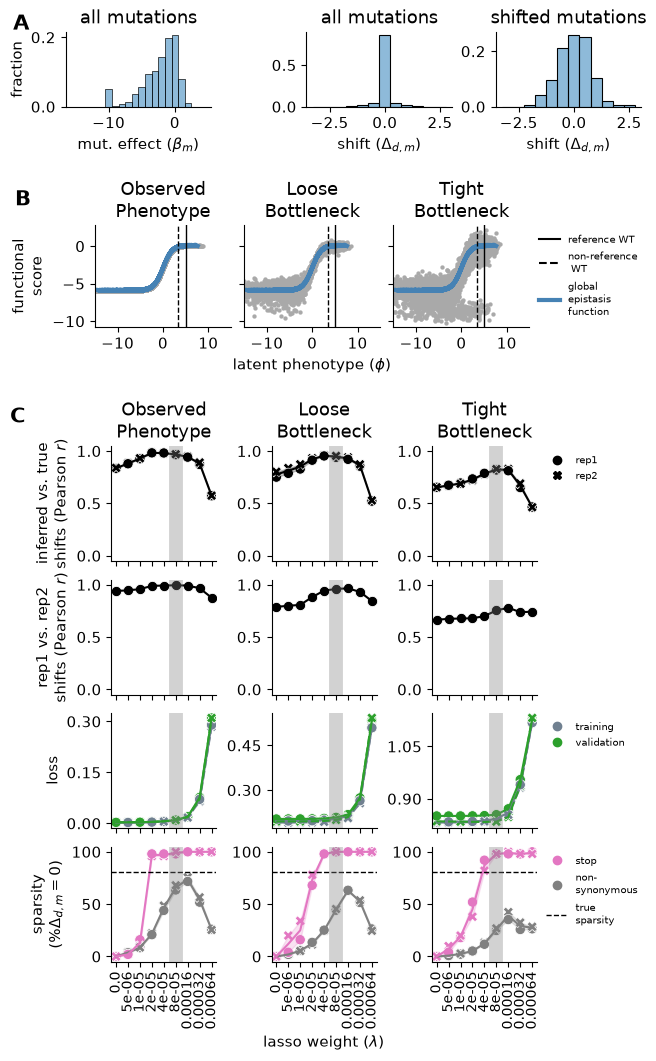

In [8]:
# ══════════════════════════════════════════════════════════════════════
# Build composite main figure (panels A–C)
# ══════════════════════════════════════════════════════════════════════

fig = plt.figure(layout="constrained", figsize=(6.4, 10.5))
A, B, C = fig.subfigures(nrows=3, ncols=1, height_ratios=[0.15, 0.2, 0.65], hspace=0.05)

# ── Panel A: Histograms ──
axd_a = A.subplot_mosaic(
    [["beta_dist", "empty", "shift_dist", "shift_dist_nonzero"]],
    gridspec_kw={"width_ratios": [1, 0.3, 1, 1], "wspace": 0.05, "hspace": 0.05},
)
axd_a["empty"].set_visible(False)

# Panel A1: Beta distribution (all mutations)
ax = axd_a["beta_dist"]
sns.histplot(
    simulated_muteffects_df,
    x="beta_h1",
    ax=ax,
    stat="probability",
    alpha=0.5,
    bins=np.arange(-15.5, 5.5, 1.0),
)
ax.set_xlabel(r"mut. effect $(\beta_m)$")
ax.set_ylabel("fraction")
ax.set_title("all mutations")

# Panel A2: Shift distribution (all mutations)
ax = axd_a["shift_dist"]
sns.histplot(
    simulated_muteffects_df,
    x="shift",
    ax=ax,
    stat="probability",
    alpha=0.5,
    bins=np.arange(-3.25, 3.25, 0.5),
)
ax.set_ylabel(None)
ax.set_xlabel(r"shift $(\Delta_{d,m})$")
ax.set_title("all mutations")

# Panel A3: Shift distribution (shifted mutations only, excluding stops)
ax = axd_a["shift_dist_nonzero"]
shifted_nonstop = simulated_muteffects_df.query(
    "shifted_site and ~mutation.str.contains('\\*')"
)
sns.histplot(
    shifted_nonstop,
    x="shift",
    ax=ax,
    stat="probability",
    alpha=0.5,
    bins=np.arange(-3.25, 3.25, 0.5),
)
ax.set_ylabel(None)
ax.set_xlabel(r"shift $(\Delta_{d,m})$")
ax.set_title("shifted mutations")

# ── Panel B: Latent phenotype vs functional score ──
axd_b = B.subplot_mosaic(
    [
        [
            "observed_phenotype_latent_measured",
            "loose_bottle_latent_measured",
            "tight_bottle_latent_measured",
        ]
    ],
    sharey=True,
)

for bottleneck, name in bottlenecks.items():
    ax = axd_b[f"{bottleneck}_latent_measured"]
    sub = simulated_func_scores_df.query(
        "library == 'lib_1' and func_score_type == @bottleneck"
    )
    n_sample = min(8000, len(sub))
    sns.scatterplot(
        sub.sample(n_sample, random_state=42),
        x="latent_phenotype",
        y="func_score",
        ax=ax,
        s=8,
        c="darkgrey",
        edgecolor="darkgrey",
    )
    # GE curve overlay (ground truth)
    sns.lineplot(
        data=gt_points,
        x="x",
        y="y",
        ax=ax,
        color=groundtruth_color,
        linestyle="-",
        linewidth=3,
    )
    # WT latent phenotype lines
    ax.axvline(reference_wt_latent, color=ref_wildtype_color, linewidth=1)
    ax.axvline(
        non_reference_wt_latent,
        color=nonref_wildtype_color,
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(name)
    ax.set_xlim(x_scale)
    if bottleneck == "observed_phenotype":
        ax.set_ylabel(observed_phenotype_ylabel)
    if bottleneck == "loose_bottle":
        ax.set_xlabel(latent_phenotype_label)
    else:
        ax.set_xlabel(None)

# ── Panel C: Diagnostic metrics (4 rows x 3 columns) ──
axd_c = C.subplot_mosaic(
    [
        [f"{b}_shift_acc" for b in bottlenecks.keys()],
        [f"{b}_shift_rep" for b in bottlenecks.keys()],
        [f"{b}_shift_cv" for b in bottlenecks.keys()],
        [f"{b}_shift_sparse" for b in bottlenecks.keys()],
    ],
    sharex=True,
    gridspec_kw={"hspace": 0.05},
)

for bottleneck, name in bottlenecks.items():

    # ── Row 1: Shift accuracy (Pearson r) ──
    ax = axd_c[f"{bottleneck}_shift_acc"]
    sub = model_vs_truth_plot.query(
        "measurement_type == @bottleneck and parameter == 'shift'"
    ).sort_values("fusionreg")
    sns.scatterplot(
        sub, x="fusionreg_idx", y="pearson_r", ax=ax,
        style="library", legend=False, s=point_size, c="black",
    )
    sns.lineplot(
        sub, x="fusionreg_idx", y="pearson_r", ax=ax,
        legend=False, c="black",
    )
    ax.set_title(name)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(model_truth_corr_ylabel if bottleneck == "observed_phenotype" else None)
    ax.set_xlabel(None)

    # ── Row 2: Replicate shift (Pearson r) ──
    ax = axd_c[f"{bottleneck}_shift_rep"]
    # Filter for shift parameter
    rep_sub = replicate_corr_plot.query("measurement_type == @bottleneck")
    if "mut_param" in rep_sub.columns:
        rep_sub = rep_sub.query("mut_param == 'shift'")
    rep_sub = rep_sub.sort_values("fusionreg")
    sns.scatterplot(
        rep_sub, x="fusionreg_idx", y="pearson_r", ax=ax,
        c="black", legend=False, s=point_size,
    )
    sns.lineplot(
        rep_sub, x="fusionreg_idx", y="pearson_r", ax=ax,
        c="black", legend=False,
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(lib_corr_ylabel if bottleneck == "observed_phenotype" else None)
    ax.set_xlabel(None)

    # ── Row 3: Cross-validation loss ──
    ax = axd_c[f"{bottleneck}_shift_cv"]
    cv_sub = cv_loss_plot.query("measurement_type == @bottleneck").sort_values("fusionreg")
    # Use mean_loss if available, otherwise fall back to loss
    loss_col = "mean_loss" if "mean_loss" in cv_sub.columns else "loss"
    sns.scatterplot(
        cv_sub, x="fusionreg_idx", y=loss_col, ax=ax,
        style="library" if "library" in cv_sub.columns else None,
        legend=False, s=point_size,
        hue="dataset" if "dataset" in cv_sub.columns else None,
        palette=dataset_palette if "dataset" in cv_sub.columns else None,
    )
    sns.lineplot(
        cv_sub, x="fusionreg_idx", y=loss_col, ax=ax,
        style="library" if "library" in cv_sub.columns else None,
        legend=False,
        hue="dataset" if "dataset" in cv_sub.columns else None,
        palette=dataset_palette if "dataset" in cv_sub.columns else None,
    )
    ax.set_ylabel(loss_ylabel if bottleneck == "observed_phenotype" else None)
    ax.set_xlabel(None)

    # ── Row 4: Sparsity ──
    ax = axd_c[f"{bottleneck}_shift_sparse"]
    # Filter for shift parameter
    sp_sub = sparsity_plot.query("measurement_type == @bottleneck")
    if "mut_param" in sp_sub.columns:
        sp_sub = sp_sub.query("mut_param.str.contains('shift')")
    sp_sub = sp_sub.sort_values("fusionreg")
    sns.scatterplot(
        sp_sub, x="fusionreg_idx", y="sparsity", ax=ax,
        style="library" if "library" in sp_sub.columns else None,
        legend=False, s=point_size,
        hue="mut_type" if "mut_type" in sp_sub.columns else None,
        palette=mut_type_palette if "mut_type" in sp_sub.columns else None,
    )
    sns.lineplot(
        sp_sub, x="fusionreg_idx", y="sparsity", ax=ax,
        legend=False,
        hue="mut_type" if "mut_type" in sp_sub.columns else None,
        palette=mut_type_palette if "mut_type" in sp_sub.columns else None,
    )
    ax.set_ylim(-5, 105)
    ax.set_ylabel(sparsity_ylabel if bottleneck == "observed_phenotype" else None)
    # True sparsity dashed line
    ax.axhline(true_sparsity, color="k", linestyle="--", linewidth=1)
    ax.set_xticks(range(len(fusionreg_vals)))
    ax.set_xticklabels([str(v) for v in fusionreg_vals], rotation=90, fontsize=10)
    if bottleneck == "loose_bottle":
        ax.set_xlabel(lasso_strength_label)
    else:
        ax.set_xlabel(None)

# ── Touchup: panel labels, ticks, legends, vertical lasso bars ──

# Panel labels
axd_a["beta_dist"].text(
    -0.25, 1.10, "A", ha="right", va="center",
    size=15, weight="bold", transform=axd_a["beta_dist"].transAxes,
)
axd_b["observed_phenotype_latent_measured"].text(
    -0.47, 1.25, "B", ha="right", va="center",
    size=15, weight="bold",
    transform=axd_b["observed_phenotype_latent_measured"].transAxes,
)
axd_c["observed_phenotype_shift_acc"].text(
    -0.82, 1.25, "C", ha="right", va="center",
    size=15, weight="bold",
    transform=axd_c["observed_phenotype_shift_acc"].transAxes,
)

sns.despine(fig)

# Fix up y-axis ticks in Panel C
for ax_name, ax in axd_c.items():
    if ax_name.endswith("shift_acc") or ax_name.endswith("shift_rep"):
        ax.set_yticks([0.0, 0.5, 1.0])
        ax.set_yticklabels(["0.0", "0.5", "1.0"])
    elif ax_name.endswith("shift_sparse"):
        ax.set_yticks([0, 50, 100])
        ax.set_yticklabels(["0", "50", "100"])
    else:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(3))
        ticks_loc = ax.get_yticks().tolist()
        ax.yaxis.set_major_locator(mticker.FixedLocator(ticks_loc))
        ax.set_yticklabels([f"{x:2.2f}" for x in ticks_loc])

    # Vertical grey bar at chosen lasso
    ax.axvline(fusionreg_idx_map[lasso_choice], color="grey", linewidth=10, alpha=0.35)

# ── Legends ──

# Panel B legend
ax = axd_b["tight_bottle_latent_measured"]
elements = [
    mlines.Line2D([], [], color=ref_wildtype_color, linestyle="-",
                  markersize=5, label="reference WT"),
    mlines.Line2D([], [], color=nonref_wildtype_color, linestyle="--",
                  markersize=5, label="non-reference\n WT"),
    mlines.Line2D([], [], color=groundtruth_color, linestyle="-", linewidth=3,
                  markersize=5, label="global\nepistasis\nfunction"),
]
ax.legend(handles=elements, bbox_to_anchor=(1.0, 1.0), loc="upper left",
          frameon=False, fontsize=7.5)

# Panel C legends
ax = axd_c["tight_bottle_shift_acc"]
elements = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="None",
                  markersize=6, label="rep1"),
    mlines.Line2D([], [], color="black", marker="X", linestyle="None",
                  markersize=6, label="rep2"),
]
ax.legend(handles=elements, bbox_to_anchor=(1.0, 1.0), loc="upper left",
          frameon=False, fontsize=7.5)

ax = axd_c["tight_bottle_shift_sparse"]
elements = [
    mlines.Line2D([], [], color=mut_type_palette["stop"], marker="o",
                  linestyle="None", markersize=6, label="stop"),
    mlines.Line2D([], [], color=mut_type_palette["nonsynonymous"], marker="o",
                  linestyle="None", markersize=6, label="non-\nsynonymous"),
    mlines.Line2D([], [], color="k", linestyle="--", linewidth=1,
                  markersize=5, label="true\nsparsity"),
]
ax.legend(handles=elements, bbox_to_anchor=(1.0, 1.0), loc="upper left",
          frameon=False, fontsize=7.5)

ax = axd_c["tight_bottle_shift_cv"]
elements = [
    mlines.Line2D([], [], color=dataset_palette["training"], marker="o",
                  linestyle="None", markersize=6, label="training"),
    mlines.Line2D([], [], color=dataset_palette["validation"], marker="o",
                  linestyle="None", markersize=6, label="validation"),
]
ax.legend(handles=elements, bbox_to_anchor=(1.0, 1.0), loc="upper left",
          frameon=False, fontsize=7.5)

# Save
fig.savefig(
    os.path.join(figures_dir, "main_figure.pdf"),
    bbox_inches="tight", dpi=300,
)
fig.savefig(
    os.path.join(figures_dir, "main_figure.png"),
    bbox_inches="tight", dpi=300,
)
print(f"Saved {os.path.join(figures_dir, 'main_figure.pdf')}")
plt.show()

## Ground-Truth Correlation Scatter

Scatter of predicted vs true mutation effects (beta) at the chosen lasso value and zero noise, with R² annotation.

Saved ground_truth_correlation.pdf  (R^2 = 0.9941)


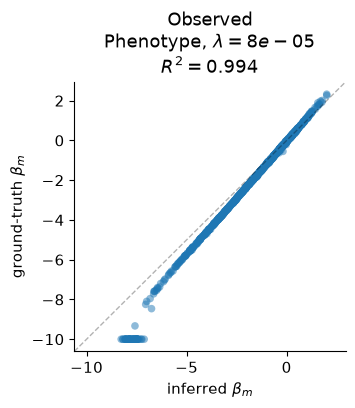

In [9]:
# Ground-truth correlation scatter for beta at chosen lasso, zero noise
measurement_type = "observed_phenotype"

beta_sub = model_vs_truth_plot.query(
    "parameter == 'beta'"
    " and measurement_type == @measurement_type"
    " and fusionreg == @lasso_choice"
)

# If we have per-mutation data in model_vs_truth_df, use it directly.
# Otherwise fall back to the summary R^2 from the metrics CSV.
# The evaluate notebook saves a summary CSV with corr per (parameter,
# measurement_type, library, fusionreg). For the scatter we need the
# underlying per-mutation predicted vs true values.
# Since this notebook loads only CSVs and the per-mutation scatter requires
# the model_df (collection_muts.csv) which may or may not exist, we check
# for it and fall back to a summary annotation if not available.

collection_muts_path = os.path.join(output_dir, "collection_muts.csv")
if os.path.exists(collection_muts_path):
    model_df = pd.read_csv(collection_muts_path)
    data = model_df.query(
        "library == 'lib_1'"
        " and measurement_type == @measurement_type"
        " and fusionreg == @lasso_choice"
    ).copy()
    if "predicted_beta" in data.columns and "true_beta" in data.columns:
        r, _ = scipy.stats.pearsonr(data["predicted_beta"], data["true_beta"])
        r2 = r ** 2

        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        ax.scatter(
            data["predicted_beta"], data["true_beta"],
            alpha=0.5, s=30, edgecolors="none",
        )
        ax.set_xlabel(r"inferred $\beta_m$")
        ax.set_ylabel(r"ground-truth $\beta_m$")
        ax.set_title(
            f"{bottlenecks[measurement_type]}, $\lambda={lasso_choice}$\n$R^2={r2:.3f}$"
        )
        # Line of identity
        lims = [
            min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1]),
        ]
        ax.plot(lims, lims, "k--", alpha=0.3, linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        sns.despine(ax=ax)

        fig.savefig(
            os.path.join(figures_dir, "ground_truth_correlation.pdf"),
            bbox_inches="tight", dpi=300,
        )
        fig.savefig(
            os.path.join(figures_dir, "ground_truth_correlation.png"),
            bbox_inches="tight", dpi=300,
        )
        print(f"Saved ground_truth_correlation.pdf  (R^2 = {r2:.4f})")
        plt.show()
    else:
        print("collection_muts.csv lacks predicted_beta/true_beta columns — "
              "skipping scatter, using summary R^2 from metrics CSV.")
        r2_val = beta_sub["r2"].values
        print(f"Summary R^2 values for beta at lasso={lasso_choice}: {r2_val}")
else:
    # Fallback: print summary from metrics CSV
    print("collection_muts.csv not found — displaying summary R^2 only.")
    if len(beta_sub) > 0:
        r2_summary = beta_sub[["library", "r2"]].to_string(index=False)
        print(f"Beta R^2 at lasso={lasso_choice}, {measurement_type}:")
        print(r2_summary)

        fig, ax = plt.subplots(figsize=(3.5, 3.5))
        ax.text(
            0.5, 0.5,
            f"Beta $R^2$ = {beta_sub['r2'].mean():.3f}\n"
            f"(scatter requires collection_muts.csv)",
            ha="center", va="center", transform=ax.transAxes, fontsize=12,
        )
        ax.set_title(f"{bottlenecks[measurement_type]}, $\lambda={lasso_choice}$")
        ax.set_xlabel(r"inferred $\beta_m$")
        ax.set_ylabel(r"ground-truth $\beta_m$")
        sns.despine(ax=ax)
        fig.savefig(
            os.path.join(figures_dir, "ground_truth_correlation.pdf"),
            bbox_inches="tight", dpi=300,
        )
        fig.savefig(
            os.path.join(figures_dir, "ground_truth_correlation.png"),
            bbox_inches="tight", dpi=300,
        )
        print(f"Saved ground_truth_correlation.pdf (summary only)")
        plt.show()

## Sparsity Diagnostic Scatter

For mutations with true shift = 0, scatter of inferred shift vs inferred beta at the chosen lasso value.

lasso_weight, sparsity (fraction shift=0)
  lambda=0.0, sparsity=0.00
  lambda=8e-05, sparsity=0.78


Saved sparsity_diagnostic.pdf


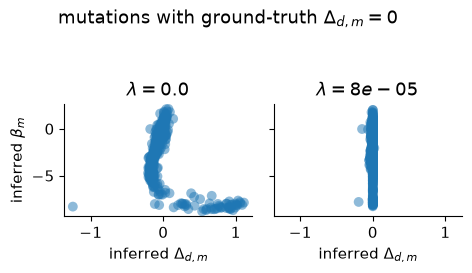

In [10]:
# Sparsity diagnostic: inferred shift vs inferred beta for true-shift-zero mutations
measurement_type = "observed_phenotype"

collection_muts_path = os.path.join(output_dir, "collection_muts.csv")
if os.path.exists(collection_muts_path):
    model_df = pd.read_csv(collection_muts_path)

    # Two panels: lasso=0 and lasso=lasso_choice
    lasso_values = sorted(set([0.0, lasso_choice]))
    # Only keep values that exist in the data
    available_lassos = model_df["fusionreg"].unique()
    lasso_values = [v for v in lasso_values if v in available_lassos]
    if len(lasso_values) == 0:
        lasso_values = [available_lassos.min(), lasso_choice]
        lasso_values = [v for v in lasso_values if v in available_lassos]

    n_panels = len(lasso_values)
    fig, axes = plt.subplots(1, n_panels, sharex=True, sharey=True,
                             figsize=(2.5 * n_panels, 2.5))
    if n_panels == 1:
        axes = [axes]

    print(f"lasso_weight, sparsity (fraction shift=0)")
    for i, lw in enumerate(lasso_values):
        data = model_df.query(
            "library == 'lib_1'"
            " and measurement_type == @measurement_type"
            " and fusionreg == @lw"
        ).copy()

        # Identify true-shift-zero mutations
        if "true_shift" in data.columns:
            data = data.query("true_shift == 0")
        elif "shift" in simulated_muteffects_df.columns:
            zero_shift_muts = set(
                simulated_muteffects_df.query("shift == 0")["mutation"]
            )
            data = data[data["mutation"].isin(zero_shift_muts)]

        # Determine shift and beta column names
        shift_col = (
            "predicted_shift_h2"
            if "predicted_shift_h2" in data.columns
            else "shift_h2" if "shift_h2" in data.columns
            else None
        )
        beta_col = (
            "predicted_beta"
            if "predicted_beta" in data.columns
            else "beta" if "beta" in data.columns
            else None
        )

        if shift_col and beta_col and len(data) > 0:
            frac_zero = (data[shift_col] == 0).sum() / len(data)
            print(f"  lambda={lw}, sparsity={frac_zero:.2f}")

            axes[i].scatter(
                data[shift_col], data[beta_col],
                alpha=0.5, s=50, edgecolors="none",
            )
            axes[i].set_xlabel(r"inferred $\Delta_{d,m}$")
            axes[i].set_title(f"$\lambda={lw}$")
        else:
            axes[i].set_title(f"$\lambda={lw}$ (no data)")
            print(f"  lambda={lw}, no suitable columns found")

    axes[0].set_ylabel(r"inferred $\beta_m$")
    fig.suptitle(
        r"mutations with ground-truth $\Delta_{d,m}=0$", y=1.08
    )
    sns.despine(fig=fig)
    fig.tight_layout()

    fig.savefig(
        os.path.join(figures_dir, "sparsity_diagnostic.pdf"),
        bbox_inches="tight", dpi=300,
    )
    fig.savefig(
        os.path.join(figures_dir, "sparsity_diagnostic.png"),
        bbox_inches="tight", dpi=300,
    )
    print(f"Saved sparsity_diagnostic.pdf")
    plt.show()
else:
    print("collection_muts.csv not found — cannot produce sparsity diagnostic scatter.")
    print("This figure requires per-mutation model predictions.")

## Mutation Effect Heatmap with WT Markers

Pivot table of shifts by site x amino acid, with WT residue markers for h1 (x) and h2 (o). Displayed inline only, not saved to PDF.

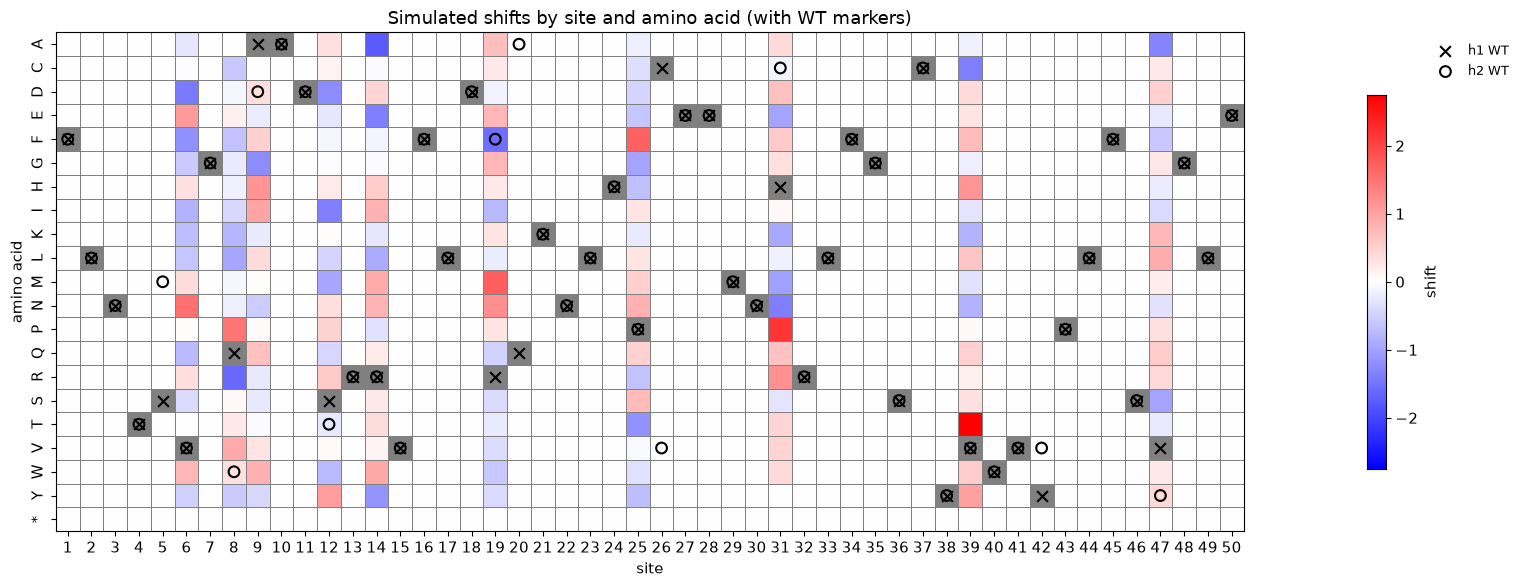

Heatmap displayed inline (not saved to file).


In [11]:
# Mutation effect heatmap with h1/h2 WT markers
aas = [
    "A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N",
    "P", "Q", "R", "S", "T", "V", "W", "Y", "*",
]

# Pivot shift values
shift_pivot = simulated_muteffects_df.pivot_table(
    index="mut_aa", columns="site", values="shift"
)
shift_pivot = shift_pivot.clip(lower=-10).reindex(aas)

# Identify WT residues for h1 and h2
h1_wt = (
    simulated_muteffects_df[["site", "wt_aa"]]
    .drop_duplicates()
    .rename(columns={"wt_aa": "wt_aa_h1"})
)
# h2 WT: if wt_aa_h2 column exists use it, otherwise infer from bundle_mut
if "wt_aa_h2" in simulated_muteffects_df.columns:
    h2_wt = (
        simulated_muteffects_df[["site", "wt_aa_h2"]]
        .drop_duplicates()
    )
else:
    # Infer h2 WT from bundle mutations
    bundle = simulated_muteffects_df.query("bundle_mut == True")
    h2_wt = bundle[["site", "mut_aa"]].drop_duplicates().rename(
        columns={"mut_aa": "wt_aa_h2"}
    )

# Build marker coordinate arrays
h1_sites, h1_aas_idx = [], []
for _, row in h1_wt.iterrows():
    site = row["site"]
    aa = row["wt_aa_h1"]
    if site in shift_pivot.columns and aa in aas:
        h1_sites.append(list(shift_pivot.columns).index(site) + 0.5)
        h1_aas_idx.append(aas.index(aa) + 0.5)

h2_sites, h2_aas_idx = [], []
for _, row in h2_wt.iterrows():
    site = row["site"]
    aa = row["wt_aa_h2"]
    if site in shift_pivot.columns and aa in aas:
        h2_sites.append(list(shift_pivot.columns).index(site) + 0.5)
        h2_aas_idx.append(aas.index(aa) + 0.5)

# Plot
fig, ax = plt.subplots(figsize=(max(12, len(shift_pivot.columns) * 0.5), 6))
sns.heatmap(
    shift_pivot,
    cmap="bwr",
    center=0,
    vmin=-2.75,
    vmax=2.75,
    square=True,
    linewidths=0.4,
    linecolor="0.5",
    cbar_kws={"shrink": 0.75, "label": "shift"},
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)
ax.set_facecolor("0.5")

# h1 WT markers (x)
ax.scatter(
    h1_sites, h1_aas_idx,
    marker="x", s=60, c="black", linewidths=1.5,
    label="h1 WT", zorder=5,
)
# h2 WT markers (o)
ax.scatter(
    h2_sites, h2_aas_idx,
    marker="o", s=60, facecolors="none", edgecolors="black", linewidths=1.5,
    label="h2 WT", zorder=5,
)

ax.set_ylabel("amino acid")
ax.set_title("Simulated shifts by site and amino acid (with WT markers)")

# Place legend outside the plot area
ax.legend(
    bbox_to_anchor=(1.15, 1.0), loc="upper left",
    frameon=False, fontsize=9,
)

sns.despine(right=False, top=False)
plt.tight_layout()
plt.show()
print("Heatmap displayed inline (not saved to file).")